In [30]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [31]:
# 데이터 로드: 구글 드라이브에 저장된 자동자 평가 데이터셋을 읽어옴
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Car_evaluation/car_evaluation.csv')
dataset.head() # 상위 5(기본값)개 데이터를 확인하여 구조 파악. 유사한 방법으로 dataset.tail() -> 이는 데이터프레임 내의 마지막 n줄의 데이터를 출력

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

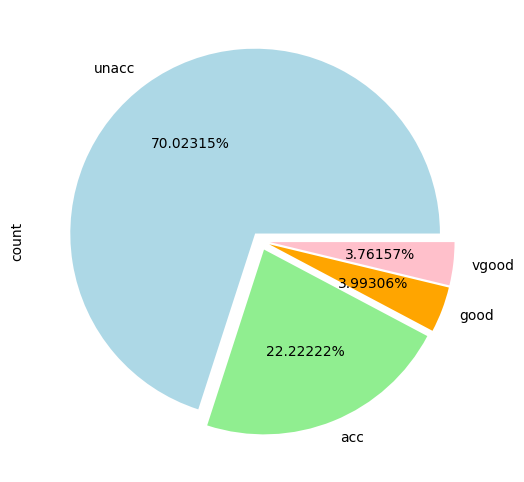

In [32]:
# 데이터셋을 이해하기 쉽게 파이차트를 통해 분포 형태 확인
# 결과에 따르면 자동차(70%)는 허용 불가능 상태. 20%는 허용 가능한 수준
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

In [33]:
# 범주형 데이터를 텐서로 변환하기 위해서는 절차가 필요: 범주형 데이터->dataset[category]->넘파이 배열(NumPy array)->텐서(Tensor)
categorical_colums = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

# astype() 메서드를 이용해 범주 특성을 갖는 데이터를 범주형(category) 타입으로 변환해야 함
for category in categorical_colums:
  dataset[category] = dataset[category].astype('category')

# 범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위해 cat.codes를 사용
# cat.codes: 범주형(Categorical) 데이터를 정수형(Integer) 레이블로 변환할 때 사용하는 속성(각 카테고리에 할당된 고유 정수값 가져옴)
# 단 어떤 클래스가 어떤 숫자로 매핑되어 있는지 확인이 어려운 단점 존재
price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

# 데이터 합치기-> 각각의 배열을 하나의 행렬로 결합
# np.stack: 두 개 이상의 넘파이 객체를 합칠 때 사용->(N,) 형태의 배열들을 열(column) 방향으로 쌓아 (N, 6) 형태로 만듦
# 1의 의미: axis=0(기본값) -> 수직으로 쌓음 / axis=1 -> 수평(열 방향)으로 쌓음
categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

In [34]:
# 텐서로 변환: 모델 입력값으로 사용하기 위해 텐서로 변환
# dtype=torch.int64: Embedding 레이어의 입력값은 보통 정수형(int64)이어야 한다.
# why? => Embedding 레이어는 입력값을 '인덱스(번호)'로 써서 값을 찾아오기 때문에
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [35]:
# 출력(Label) 데이터 전처리: 정답 데이터를 one-hot encoding 후 텐서화한다.
# get_dummies: 가변수로 만들어 주는 함수(가변수로 만들어 준다는 의미는 문자를 숫자(0, 1)로 바꾸어 준다는 의미)
outputs = pd.get_dummies(dataset.output) # 텍스트 레이블을 [0, 1, 0, ...] 형태의 벡터로 변환
outputs = outputs.values # NumPy 배열로 변환
outputs = torch.tensor(outputs).flatten() # 텐서 변환 후 1차원으로 평탄화(학습 시 차원 맞춤)

# 텐서의 크기 확인
print(categorical_data.shape) # 입력(전체행수, 6개 특징)
print(outputs.shape) # 출력

torch.Size([1728, 6])
torch.Size([6912])


In [36]:
# 각 컬럼별 범주(category)의 개수 구하기
# ex: 'price' 칼럼에 [low, mid, high]가 있다면 개수 3개
categorical_colum_sizes = [len(dataset[column].cat.categories) for column in categorical_colums]

# 각 범주형 데이터를 몇 차원의 벡터로 바꿀지 결정
# (범주 개수, 임베딩 차원) 형태로 튜플 리스트 만듦.
# min(50, (col_size+1)//2) -> 범주 절반 정도로 차원을 정하되, 최대 50은 넘지 않게 설정하는 관례적인 공식
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_colum_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [37]:
# 데이터셋 분리
# 전체 데이터 개수와 테스트에 사용할 비율(20%) 정하기
total_records = 1728
test_records = int(total_records * .2)

# 범주형 입력 데이터 분할
# [시작:끝] -> 처음부터 (전체-테스트개수) 전까지 = 학습용(80%)
categorical_train_data = categorical_data[:total_records - test_records]

# [(전체-테스트개수):끝까지] = 테스트용(20%)
categorical_test_data = categorical_data[total_records - test_records:total_records]

# 정답 데이터 분할
# 입력 데이터와 똑같은 지점에서 잘라야 '문제'와 '정답'이 서로 맞음
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [38]:
# 클래스 형태로 구현되는 모델은 nn.Module을 상속받는다.
class Model(nn.Module):
  # __init__()은 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출
  def __init__(self, embedding_size, output_size, layers, p=0.4):
    super().__init__() # 부모 클래스(nn.Module)에 접근할 때 사용
    # [임베딩 층] 각 컬럼마다 개별적인 임베딩 공간을 만듦
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
    # [드롭아웃] 학습 시 일부 노드를 dropout하여 과적합(단순 암기)을 방지
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    # [입력 크기 계산] 임베딩된 벡터들의 총 길이를 합쳐서 첫 번째 레이어의 입력 크기로 정함
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols

    # [은닉층 쌓기] 리스트로 받은 레이어 설정(ex: [200, 100])대로 층을 반복해서 쌓는다.
    for i in layers:
      all_layers.append(nn.Linear(input_size, i)) # 선형 결합(행렬 곱)
      all_layers.append(nn.ReLU(inplace=True))  # 활성화 함수(비선형성 추가)
      all_layers.append(nn.BatchNorm1d(i))  # 배치 정규화(학습 안정화)
      all_layers.append(nn.Dropout(p))  # 드롭아웃
      input_size = i  # 다음 층의 입력 크기는 현재 층의 출력 크기가 된다.

    # [출력층] 마지막 레이어에서 최종 정답 개수(output_size)만큼 결과를 내보냄
    all_layers.append(nn.Linear(layers[-1], output_size))

    # [순차적 실행] 위에서 만든 모든 층을 하나로 묶음
    self.layers = nn.Sequential(*all_layers)

  # 순전파: 데이터가 모델을 통과하는 실제 과정을 정의
  def forward(self, x_categorical):
    embeddings = []
    # 각 컬럼 데이터를 해당하는 임베딩 층에 통과시켜 숫자로 바꿈
    for i, e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))

    # [결합] 따로 노는 임베딩 벡터들을 옆으로 길게 하나로 합침
    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x) # 드롭아웃 적용

    # [층 통과] 준비된 은닉층들을 차례대로 통과한다.
    x = self.layers(x)
    return x

In [39]:
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [40]:
# 손실 함수: 모델의 예측값과 실제 정답 사이의 거리를 계산
# nn.CrossEntropyLoss: 분류(Classification) 문제에서 가장 많이 쓰임, 내부적으로 Softmax 함수를 포함하고 있어 출력값을 확률로 변환해 비교
loss_function = nn.CrossEntropyLoss()

# 옵티마이저: 손실 함수를 줄이기 위해 모델의 가중치(Weight)를 업데이트.
# model.parameters(): 업데이트할 대상인 모델의 모든 가중치들을 전달
# lr=0.001: 학습률(Learning Rate)로, 한 번에 가중치를 얼마나 크게 수정할지 정한다.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [42]:
epochs = 500
aggregated_losses = [] # 각 에폭(Epoch)마다 발생하는 손실 값을 기록

# 정답 데이터를 모델이 요구하는 정수형으로 변환하고 CPU/GPU로 보냄
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
  i += 1
  # Forward Pass: 모델에 입력 데이터를 넣어 예측값을 얻는다.
  y_pred = model(categorical_train_data).to(device)
  # Loss 계산: 예측값과 실제 정답을 비교하여 오차를 구함
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 == 1:
    print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

  # 기울기 초기화: 이전 에폭에서 계산된 기울기 값을 0으로 비운다.
  optimizer.zero_grad()
  # Backward Pass(역전파): 오차를 바탕으로 각 가중치가 수정되어야 할 기울기를 계산한다.
  single_loss.backward()
  # Weight Update: 계산된 기울기를 보고 옵티마이저(Adam)가 실제로 가중를 수정한다.
  optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.60782278
epoch:  26 loss: 1.41244876
epoch:  51 loss: 1.31743646
epoch:  76 loss: 1.21119595
epoch: 101 loss: 1.09835804
epoch: 126 loss: 0.94570243
epoch: 151 loss: 0.83666754
epoch: 176 loss: 0.75066960
epoch: 201 loss: 0.69948477
epoch: 226 loss: 0.65636873
epoch: 251 loss: 0.64926708
epoch: 276 loss: 0.62221909
epoch: 301 loss: 0.61846769
epoch: 326 loss: 0.58902079
epoch: 351 loss: 0.60687160
epoch: 376 loss: 0.58098543
epoch: 401 loss: 0.58654195
epoch: 426 loss: 0.58176035
epoch: 451 loss: 0.58397645
epoch: 476 loss: 0.57507992
epoch: 500 loss: 0.5754005909


In [43]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)

# 기울기 계산 비활성화
# with torch.no_grad(): 블록 안에서는 파이토치가 가중치 수정을 위한 기울기를 계산하지 않는다.
# 테스트 시에는 모델을 고칠 필요가 없으므로, 메모리를 아끼고 속도를 높이기 위해 사용
with torch.no_grad():
  # 예측: 학습된 모델에 테스트 데이터를 넣어 결과(y_val)를 얻는다.
  y_val = model(categorical_test_data)
  # 손실 계산: 테스트 데이터에 대한 오차(Loss)가 얼마나 되는지 확인
  loss = loss_function(y_val, test_outputs)

print(f'Loss: {loss:.8f}')

Loss: 0.57304198


In [44]:
print(y_val[:5])

tensor([[ 1.3072,  0.6267, -2.3548, -2.3409],
        [ 1.8305,  0.9167, -3.4517, -3.3713],
        [ 4.5842,  2.8063, -5.3703, -5.8509],
        [ 2.2851,  1.3910, -2.6374, -2.6946],
        [ 4.9287,  2.8270, -6.5219, -7.1828]])


In [45]:
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# confusion_matrix: 모델이 어떤 클래스를 무엇으로 착각했는지 표로 보여줌
# 가로(예측)와 세로(실제)가 만나는 지점을 통해 오답의 패턴을 파악
print(confusion_matrix(test_outputs, y_val))

# classification_report: 주요 지표들을 한 눈에 보여줌
# Precision(정밀도), Recall(재현율), F1-score 등을 클래스별로 산출
print(classification_report(test_outputs, y_val))

# Accuracy: 전체 테스트 데이터 중 맞힌 개수의 비율(0~1 사이 값)
print(accuracy_score(test_outputs, y_val))

[[258   1]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.50      0.01      0.02        86

    accuracy                           0.75       345
   macro avg       0.63      0.50      0.44       345
weighted avg       0.69      0.75      0.65       345

0.7507246376811594
